In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [16]:
# Load data (edit filename or URL)
df = pd.read_csv("/sales_data.csv")

# Inspect
print(df.head())
print(df.info())

        Month  Sales
0  2023-01-01   1200
1  2023-02-01   1350
2  2023-03-01   1280
3  2023-04-01   1420
4  2023-05-01   1500
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Month   24 non-null     object
 1   Sales   24 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 516.0+ bytes
None


In [17]:
# Adjust column names as per your file
date_col = "Month"   # e.g. "Month" or "Date"
target_col = "Sales" # e.g. "Sales" or "Value"

df[date_col] = pd.to_datetime(df[date_col])
df = df.sort_values(by=date_col).reset_index(drop=True)

print(df[[date_col, target_col]].head())

       Month  Sales
0 2023-01-01   1200
1 2023-02-01   1350
2 2023-03-01   1280
3 2023-04-01   1420
4 2023-05-01   1500


In [18]:
# Check missing
print(df.isna().sum())

# Simple strategy: drop rows where target is missing
df = df.dropna(subset=[target_col])

# If date has gaps, we usually keep them; for a simple assignment this is okay.
print("After cleaning:", df.shape)

Month    0
Sales    0
dtype: int64
After cleaning: (24, 2)


In [19]:
# Numeric time index (1, 2, 3, ...)
df["time_index"] = np.arange(1, len(df) + 1)

X = df[["time_index"]]
y = df[target_col]

In [20]:
# 80% train, 20% test (time-based split)
train_size = int(len(df) * 0.8)

X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]
dates_train = df[date_col].iloc[:train_size]
dates_test = df[date_col].iloc[train_size:]

len(X_train), len(X_test)

(19, 5)

In [21]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept:", model.intercept_)
print("Coefficient:", model.coef_[0])

Intercept: 1143.3333333333335
Coefficient: 66.35087719298244


In [22]:
y_pred_test = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)

MAE : 54.94736842105285
MSE : 3174.8279470606585
RMSE: 56.34561160428253


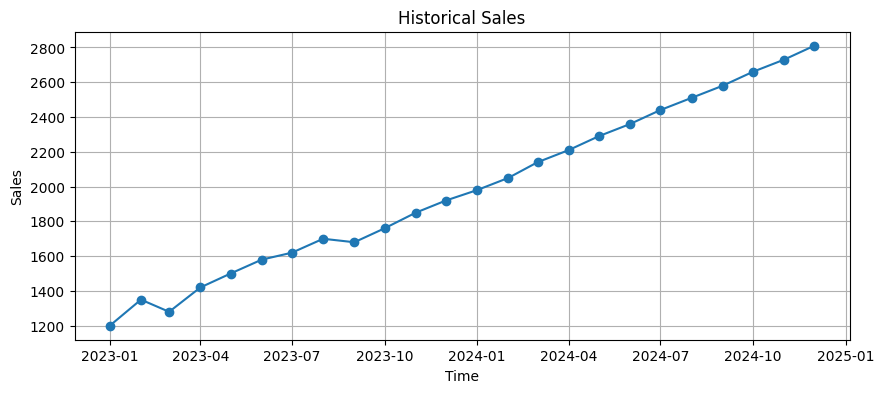

In [23]:
plt.figure(figsize=(10, 4))
plt.plot(df[date_col], df[target_col], marker='o')
plt.title("Historical " + target_col)
plt.xlabel("Time")
plt.ylabel(target_col)
plt.grid(True)
plt.show()

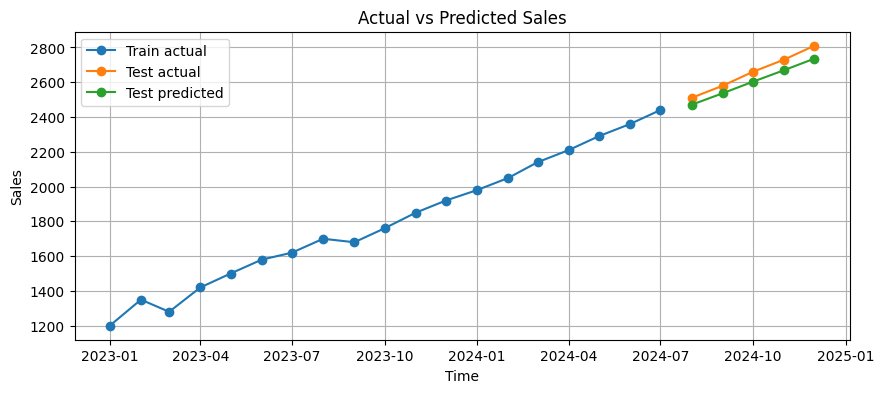

In [24]:
plt.figure(figsize=(10, 4))

# Train actuals
plt.plot(dates_train, y_train, label="Train actual", marker='o')

# Test actuals
plt.plot(dates_test, y_test, label="Test actual", marker='o')

# Test predictions
plt.plot(dates_test, y_pred_test, label="Test predicted", marker='o')

plt.title("Actual vs Predicted " + target_col)
plt.xlabel("Time")
plt.ylabel(target_col)
plt.legend()
plt.grid(True)
plt.show()

In [25]:
# How many future periods to forecast
n_future = 6

last_index = df["time_index"].iloc[-1]
future_indices = np.arange(last_index + 1, last_index + n_future + 1).reshape(-1, 1)
future_preds = model.predict(future_indices)

print("Future indices:", future_indices.flatten())
print("Future predictions:", future_preds)

Future indices: [25 26 27 28 29 30]
Future predictions: [2802.10526316 2868.45614035 2934.80701754 3001.15789474 3067.50877193
 3133.85964912]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [26]:
# Forecast next 6 months
n_future = 6

last_index = df["time_index"].iloc[-1]
future_indices = np.arange(last_index + 1, last_index + n_future + 1).reshape(-1, 1)
future_preds = model.predict(future_indices)

last_date = df[date_col].iloc[-1]
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=n_future, freq='MS')

forecast_df = pd.DataFrame({
    "Month": future_dates,
    "Predicted_Sales": future_preds
})

forecast_df

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


,Month,Predicted_Sales
0,2025-01-01,2802.105263
1,2025-02-01,2868.456140
2,2025-03-01,2934.807018
3,2025-04-01,3001.157895
4,2025-05-01,3067.508772
5,2025-06-01,3133.859649


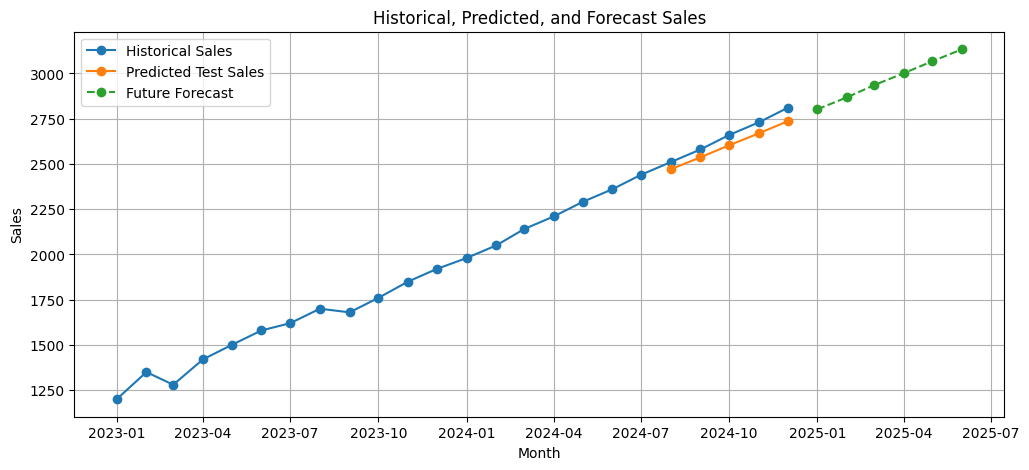

In [27]:
plt.figure(figsize=(12,5))

plt.plot(df[date_col], df[target_col], label="Historical Sales", marker='o')
plt.plot(dates_test, y_pred_test, label="Predicted Test Sales", marker='o')
plt.plot(forecast_df["Month"], forecast_df["Predicted_Sales"], label="Future Forecast", marker='o', linestyle='--')

plt.title("Historical, Predicted, and Forecast Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()